In [1]:
from scipy.stats import ttest_ind
import helper 
import xarray as xr 
import numpy as np 
import cmaps as cmap 
import matplotlib.pyplot as plt
import scipy 
import warnings
import matplotlib.patheffects as pe
from matplotlib.colors import Normalize
from matplotlib import rcParams
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle
import matplotlib.patheffects as pe
warnings.filterwarnings("ignore")

def rePoPolar(dataset, name, offset):
    x = dataset.lon.values / 4
    y = dataset.lat.values / 4
    x, y = np.meshgrid(x, y)

    R = 6371.0
    cphi = np.cos(np.deg2rad(y))
    x = R * np.deg2rad(x) * cphi
    y = R * np.deg2rad(y)

    r = np.sqrt(x**2 + y**2)
    t = np.arctan2(y, x)

    rBins = np.linspace(np.nanmin(r), np.nanmax(r), 120)
    tBins = np.linspace(np.nanmin(t), np.nanmax(t), 360)

    for i in range(len(tBins)):
            tBins[i] = tBins[i] + offset
            while tBins[i] <= (-1 * np.pi):
                tBins[i] = tBins[i] + (2 * np.pi)
            while tBins[i] >= np.pi:
                tBins[i] = tBins[i] - (2 * np.pi)

    R, T = np.meshgrid(rBins, tBins)
    newX, newY = R * np.cos(T), R * np.sin(T)
    gridded_data = scipy.interpolate.griddata((x.flatten(), y.flatten()), dataset.values.flatten(), (newX.flatten(), newY.flatten()), method='nearest')

    polar = xr.Dataset(
        {
            name: (('r', 'theta'), gridded_data.reshape(R.shape).transpose())
        },
        coords={
            'r': rBins,
            'theta': tBins
        }
    )

    return polar


In [2]:
dataset = xr.open_dataset(r"C:\Users\deela\Downloads\TCRADAR_ERA5.nc")
print(dataset)
print(list(dataset.variables))

<xarray.Dataset> Size: 13GB
Dimensions:      (case: 1510, level: 17, lon: 121, lat: 121)
Coordinates:
  * level        (level) int16 34B 200 250 300 350 400 ... 800 850 900 950 1000
  * case         (case) int64 12kB 29 29 29 29 30 ... 3713 3715 3715 3715 3715
  * lon          (lon) int64 968B -60 -59 -58 -57 -56 -55 ... 55 56 57 58 59 60
  * lat          (lat) int64 968B -60 -59 -58 -57 -56 -55 ... 55 56 57 58 59 60
Data variables: (12/28)
    rlhum        (case, level, lon, lat) float32 2GB ...
    sphum        (case, level, lon, lat) float32 2GB ...
    u_data       (case, level, lon, lat) float32 2GB ...
    v_data       (case, level, lon, lat) float32 2GB ...
    temperature  (case, level, lon, lat) float32 2GB ...
    height       (case, level, lon, lat) float32 2GB ...
    ...           ...
    fdelta_vmax  (case) float32 6kB ...
    bdelta_vmax  (case) float32 6kB ...
    system_type  (case) <U2 12kB ...
    uspd         (case) float32 6kB ...
    vspd         (case) float32 6k

In [3]:
def process(data, ddir):
    dataList = []
    os = []
    print(len(data.case))
    for x in range(len(data.case)):
        print(x)
        offset = np.deg2rad(360 - ddir.isel(case = x))
        os.append(offset)
        try:
            temp = rePoPolar(data.isel(case = x), 'rh', offset = offset)
        except:
            temp = xr.Dataset(
                {
                    var: (temp[var].dims, np.full_like(temp[var], np.nan))
                    for var in temp.data_vars
                },
                coords=temp.coords,
                attrs=temp.attrs)

        dataList.append(temp)

    newTheta = np.linspace(-np.pi, np.pi, 360, endpoint=False)
    for x in range(len(dataList)):
        try:
            dataList[x] = dataList[x].interp(theta = newTheta)    
            dataList[x]['rh'].values = np.flip(dataList[x]['rh'].values, axis = 1)
        except:
            pass

    rh = xr.concat(dataList, dim = 'case')
    print(rh)  

    return rh, newTheta, os

In [4]:
alignment = [225, 251, 252, 253, 254, 333, 334, 347, 374, 376, 377, 407, 408, 409, 410, 413, 414, 603, 604, 605, 672, 712, 719, 752, 765, 864, 878, 879, 939, 941, 957, 968, 969, 970, 971, 1057, 1073, 1101, 1128, 1131, 1148, 1177, 1178, 1179, 1180, 1191, 1192, 1220, 1221, 1222, 1223, 1224, 1226, 1227, 1228, 1302, 1379, 1380, 1391, 1405, 1406, 1445, 1446, 1447, 1448, 1453, 1471]
misalign = [148, 149, 223, 224, 339, 340, 341, 342, 343, 344, 382, 383, 384, 386, 400, 402, 423, 424, 425, 426, 427, 429, 430, 431, 545, 600, 601, 742, 744, 745, 747, 757, 760, 869, 898, 899, 918, 919, 930, 934, 935, 936, 1042, 1052, 1174, 1175, 1195, 1197, 1201, 1217, 1218, 1372, 1373, 1376, 1377, 1408, 1410, 1418, 1419]

newTheta = np.linspace(-np.pi, np.pi, 360, endpoint=False)
varShort = 'rh'

In [5]:
def labels(ax, flag = False):
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    if flag == False:
        ax.text(1 * np.pi / 4, 1000, 'Downshear\nRight', size = 12, color = 'black', horizontalalignment = 'center', fontfamily = 'Courier New', fontweight = 'bold', path_effects=[pe.withStroke(linewidth=2.25, foreground="white")], verticalalignment = 'center')
        ax.text(3 * np.pi / 4, 1000, 'Upshear\nRight', size = 12, color = 'black', horizontalalignment = 'center', fontfamily = 'Courier New', fontweight = 'bold', path_effects=[pe.withStroke(linewidth=2.25, foreground="white")], verticalalignment = 'center')
        ax.text(5 * np.pi / 4, 1000, 'Upshear\nLeft', size = 12, color = 'black', horizontalalignment = 'center', fontfamily = 'Courier New', fontweight = 'bold', path_effects=[pe.withStroke(linewidth=2.25, foreground="white")], verticalalignment = 'center')
        ax.text(7 * np.pi / 4, 1000, 'Downshear\nLeft', size = 12, color = 'black', horizontalalignment = 'center', fontfamily = 'Courier New', fontweight = 'bold', path_effects=[pe.withStroke(linewidth=2.25, foreground="white")], verticalalignment = 'center')
        
        ax.annotate('', xy=(0, 500), xytext=(np.pi, 500),
                arrowprops=dict(facecolor='black', edgecolor='black', width=1, headwidth=8, headlength=10, path_effects=[pe.withStroke(linewidth=2.25, foreground="white")]))

    ax.set_yticklabels(['', '200km', '', '600km', '', '1000km', '', ''], fontfamily = 'Courier New', path_effects=[pe.withStroke(linewidth=2.25, foreground="white")])
    ax.set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'], fontfamily = 'Courier New', path_effects=[pe.withStroke(linewidth=2.25, foreground="white")])


In [6]:
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

def relh():
    newcmp = LinearSegmentedColormap.from_list("",[
    (0/100, "#000000"),
    (15/100, "#2e2e2e"),
    (25/100, "#4d2417"),
    (35/100, "#6e3e04"),
    (45/100, "#c7ad8d"),

    (50/100, "#FFFFFF"),
    
    (55/100, "#5c9d8d"),
    (65/100, "#1f5725"),
    (75/100, "#1f2f40"),
    (85/100, "#100729"),
    (100/100, "#385484")])

    return newcmp

In [7]:
def Gradient2D(data, short = False):
    if short == True:
        lon = 'lon'
        lat = 'lat'
    else:
        lon = 'longitude'
        lat = 'latitude'

    dAx = data.diff(lon)
    dAy = data.diff(lat)

    dx = data[lon].diff(lon) * np.cos(20*np.pi/180) * (0.25*111_200)
    dy = data[lat].diff(lat) * (0.25*111_200)

    dx = dx.broadcast_like(dAx)
    dy = dy.broadcast_like(dAx)

    return dAx / dx, dAy / dy

In [8]:
def rectangle(data):
    R, TH = np.meshgrid(data.r, newTheta, indexing='ij')

    xCoord = R * np.cos(TH)
    yCoord = R * np.sin(TH)

    points = np.column_stack([xCoord.ravel(), yCoord.ravel()])
    values = data.values.ravel()

    Rmax = float(data.r.max())
    # same resolution as your r-array, but centered
    x = np.linspace(-Rmax, Rmax, data.r.size)
    y = np.linspace(-Rmax, Rmax, data.r.size)
    Xt, Yt = np.meshgrid(x, y, indexing='xy')

    print(points.shape, values.shape, Xt.shape, Yt.shape)

    rhXY = scipy.interpolate.griddata(points, values, (Xt, Yt), method='linear')

    return Yt, Xt, rhXY

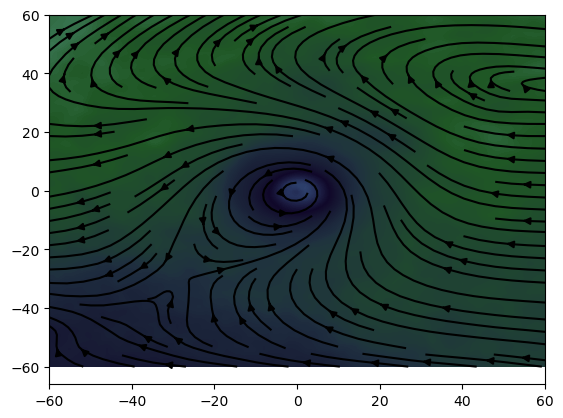

In [9]:
caseNum = 1500
testU = dataset['u_data'].sel(level = 850)
testU = testU.mean('case')#.isel(case = caseNum)
testV = dataset['v_data'].sel(level = 850)
testV = testV.mean('case')#.isel(case = caseNum)
testRH = dataset['rlhum'].sel(level = 850)
testRH = testRH.mean('case')#.isel(case = caseNum)
plt.contourf(testU.lon.values, testV.lat.values, testRH, cmap = relh(), vmin = 0, vmax = 100, levels = 100)
plt.streamplot(testU.lon.values, testV.lat.values, testU, testV, color = 'black')
plt.show()

In [274]:
hgt = 950
data = dataset['u_data']
data = data.sel(level = hgt)
ddir = dataset['shear_dir']
u, newTheta, offsets = process(data, ddir)

data = dataset['v_data']
data = data.sel(level = hgt)
ddir = dataset['shear_dir']
v, newTheta, offsets = process(data, ddir)

data = dataset['sphum']
data = data.sel(level = hgt)
ddir = dataset['shear_dir']
q, newTheta, offsets = process(data, ddir)

data = dataset['temperature']
data = data.sel(level = hgt)
ddir = dataset['shear_dir']
t, newTheta, offsets = process(data, ddir)

1510
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
2

In [275]:
offsets = xr.DataArray(np.array(offsets), dims=['case'], coords={'case': u.case})
u_orig = u[varShort].copy()
v_orig = v[varShort].copy()

u[varShort] = u_orig * np.cos(offsets) + v_orig * np.sin(offsets)
v[varShort] = -u_orig * np.sin(offsets) + v_orig * np.cos(offsets)

In [276]:
u1 = u[varShort].sel(case = alignment, r = slice(0, 1500)).mean('case')
u2 = u[varShort].sel(case = misalign, r = slice(0, 1500)).mean('case')
U = [u1, u2, u1 - u2]

v1 = v[varShort].sel(case = alignment, r = slice(0, 1500)).mean('case')
v2 = v[varShort].sel(case = misalign, r = slice(0, 1500)).mean('case')
V = [v1, v2, v1 - v2]

q1 = q[varShort].sel(case = alignment, r = slice(0, 1500)).mean('case')
q2 = q[varShort].sel(case = misalign, r = slice(0, 1500)).mean('case')
Q = [q1, q2, q1 - q2]

t1 = t[varShort].sel(case = alignment, r = slice(0, 1500)).mean('case')
t2 = t[varShort].sel(case = misalign, r = slice(0, 1500)).mean('case')
T = [t1, t2, t1 - t2]

tDat, qDat, uDat, vDat = [], [], [], []

for i in U:
    X, Y, uData = rectangle(i)
    uDat.append(uData)
for i in V:
    X, Y, vData = rectangle(i)
    vDat.append(vData)
for i in Q:
    X, Y, qData = rectangle(i)
    qDat.append(qData)
for i in T:
    X, Y, tData = rectangle(i)
    tDat.append(tData)

(27720, 2) (27720,) (77, 77) (77, 77)
(27720, 2) (27720,) (77, 77) (77, 77)
(27720, 2) (27720,) (77, 77) (77, 77)
(27720, 2) (27720,) (77, 77) (77, 77)
(27720, 2) (27720,) (77, 77) (77, 77)
(27720, 2) (27720,) (77, 77) (77, 77)
(27720, 2) (27720,) (77, 77) (77, 77)
(27720, 2) (27720,) (77, 77) (77, 77)
(27720, 2) (27720,) (77, 77) (77, 77)
(27720, 2) (27720,) (77, 77) (77, 77)
(27720, 2) (27720,) (77, 77) (77, 77)
(27720, 2) (27720,) (77, 77) (77, 77)


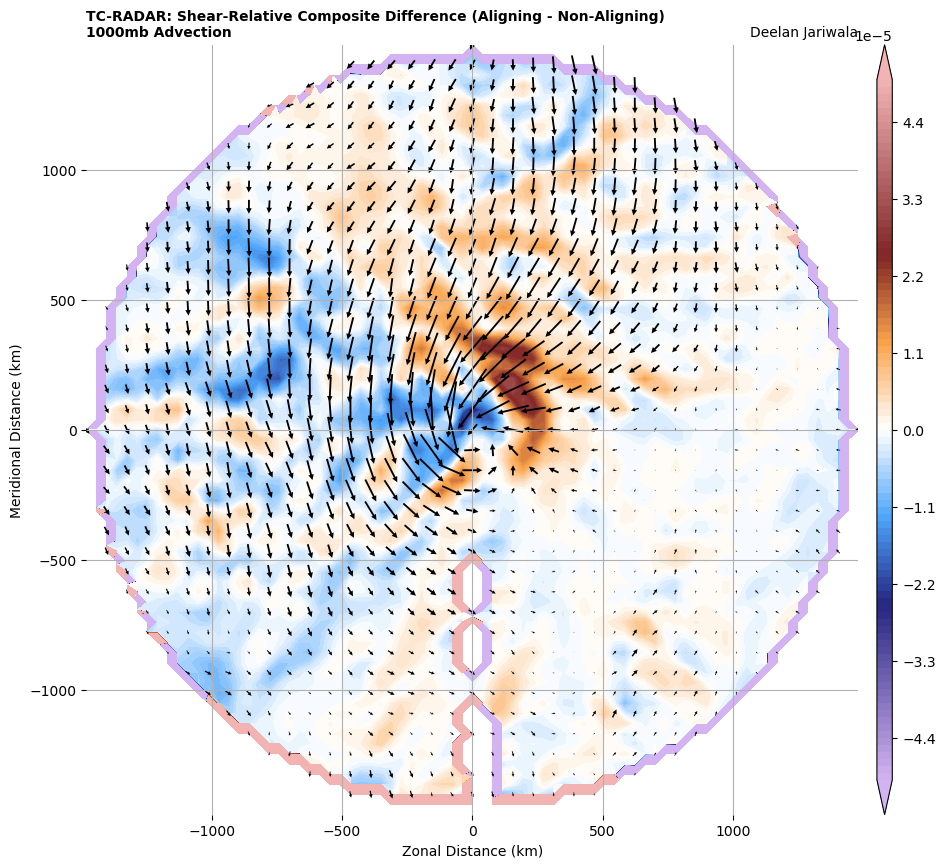

In [164]:
index = 0
tx, ty = np.gradient(np.nan_to_num(tDat[index], nan = 0.0), np.nan_to_num(Y[0, :], nan = 0.0), np.nan_to_num(X[:, 0], nan = 0.0))
fxx, fxy = np.gradient(np.nan_to_num(uDat[index], nan = 0.0), np.nan_to_num(Y[0, :], nan = 0.0), np.nan_to_num(X[:, 0], nan = 0.0))
fyx, fyy = np.gradient(np.nan_to_num(vDat[index], nan = 0.0), np.nan_to_num(Y[0, :], nan = 0.0), np.nan_to_num(X[:, 0], nan = 0.0))
# grad = sX * uData + sY * vData

adv = (-(uDat[index] * tx + vDat[index] * ty)) / 1000
# cnv = -tData * (fxx + fyy)
# mfc = adv + cnv

# Creates the plot
fig = plt.figure(figsize=(12, 10))
ax = plt.axes()
# ax.set_xlim(-1000, 1000)
# ax.set_ylim(-1000, 1000)
ax.set_ylabel('Meridional Distance (km)')
ax.set_xlabel('Zonal Distance (km)')
ax.grid()
ax.set_frame_on(False)

ax.set_title(f'TC-RADAR: Shear-Relative Composite Difference (Aligning - Non-Aligning)\n{str(hgt)}mb Advection', fontweight='bold', fontsize=10, loc='left')
ax.set_title('Deelan Jariwala', fontsize=10, loc='right') 
# c = plt.contourf(X, Y, fxx + fyy, shading='auto', cmap=cmap.tempAnoms(), levels = np.arange(-.1, .1005, 0.0005), extend = 'both')
# c = plt.contourf(X, Y, fyx - fxy, shading='auto', cmap=cmap.tempAnoms(), levels = np.arange(-.1, .1005, 0.0005), extend = 'both')
c = plt.contourf(X, Y, adv, shading='auto', cmap=cmap.tempAnoms(), levels = np.arange(-0.00005, 0.00005, .000001), extend = 'both')
cb = plt.colorbar(c, orientation = 'vertical', aspect = 50, pad = .02)

plt.quiver(X[::2, ::2], Y[::2, ::2], uDat[index][::2, ::2], vDat[index][::2, ::2], pivot = 'middle', scale = 150, minshaft = 2, minlength=0, headaxislength = 3, headlength = 3, color = 'black')
# plt.savefig(r"C:\Users\deela\Downloads\\vvelWind" + str(hgt) + ".png", dpi = 400, bbox_inches = 'tight')
plt.show()

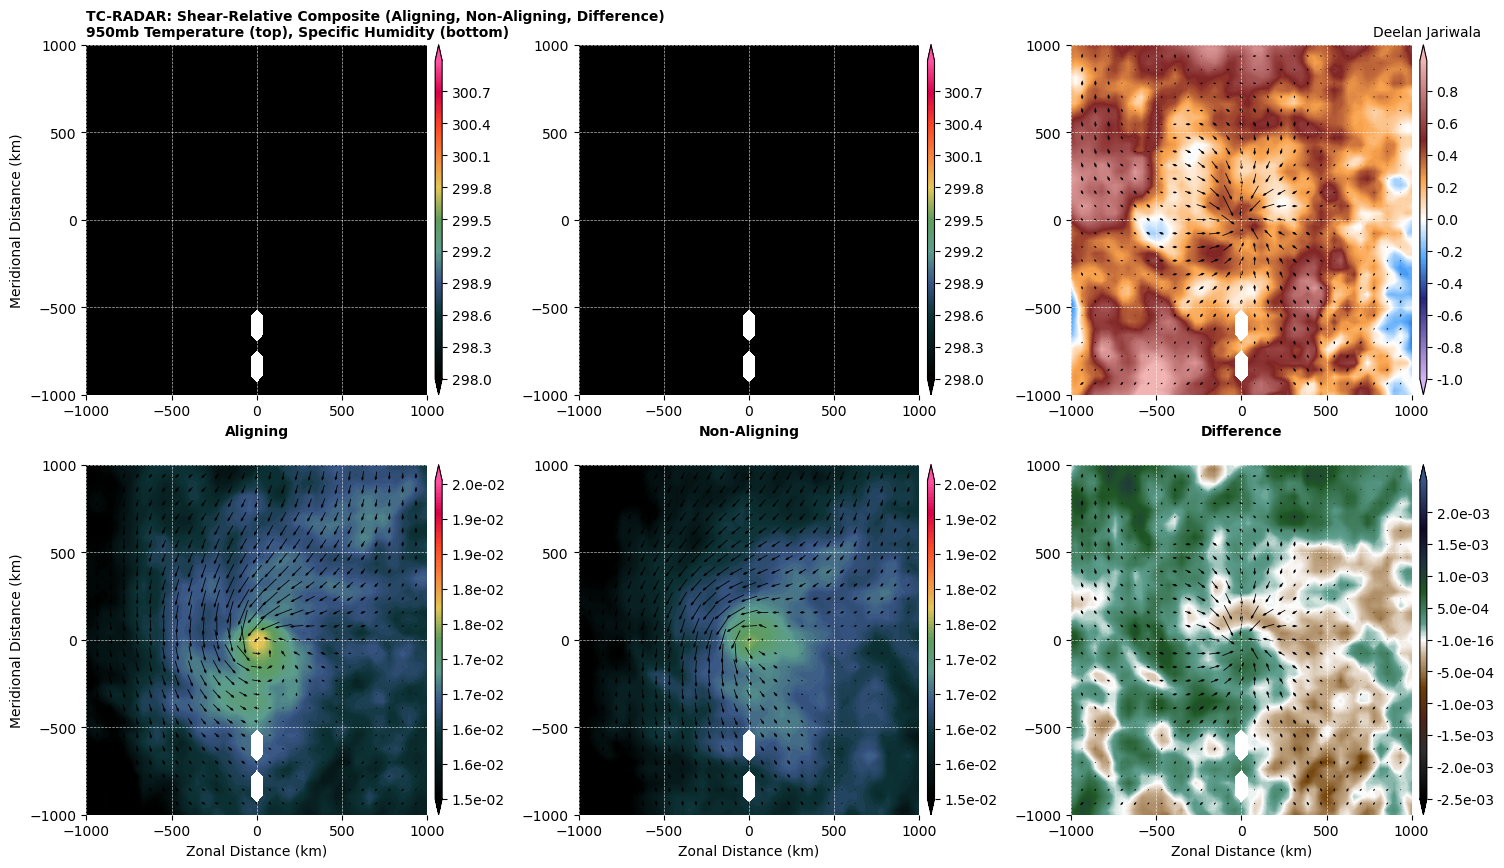

In [280]:
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 3)

axes = [fig.add_subplot(1, 1, 1),
        fig.add_subplot(gs[0, 0]),
        fig.add_subplot(gs[0, 1]),
        fig.add_subplot(gs[0, 2]),
        fig.add_subplot(gs[1, 0]),
        fig.add_subplot(gs[1, 1]),
        fig.add_subplot(gs[1, 2]),
        ]

axes[0].set_xticks([])
axes[0].set_yticks([])
axes[0].set_frame_on(False)

var = tDat
flag = False
for ax in axes:
	if ax == axes[0]:
		i = 0
		continue
	if i > 2 and flag == False:
		var = qDat 
		i = i - 3
		flag = True
	
	ax.set_xlim(-1000, 1000)
	ax.set_ylim(-1000, 1000)
	ax.grid(linestyle = '--', alpha = 0.75, color = 'white', linewidth = 0.5, zorder = 9)
	ax.set_yticks(np.arange(-1000, 1500, 500))
	ax.set_xticks(np.arange(-1000, 1500, 500))

	if i == 0:
		ax.set_ylabel('Meridional Distance (km)')
	if flag == True:
		ax.set_xlabel('Zonal Distance (km)')
	else:
		if i == 0:
			ax.set_xlabel('Aligning', fontdict={'weight':'bold'})
		elif i == 1:
			ax.set_xlabel('Non-Aligning', fontdict={'weight':'bold'})
		else:
			ax.set_xlabel('Difference', fontdict={'weight':'bold'})
	ax.set_frame_on(False)

	if hgt in [1000, 950]:
		if flag == False and i == 2:
			c = ax.contourf(X, Y, var[i], shading='auto', cmap=cmap.tempAnoms(), levels = np.arange(-1, 1, 1e-2), extend = 'both')
		elif flag == True and i == 2:
			c = ax.contourf(X, Y, var[i], shading='auto', cmap = relh(), levels = np.arange(-2.5e-3, 2.5e-3, 2.5e-6), extend = 'both')
		elif flag == True:
			c = ax.contourf(X, Y, var[i], shading='auto', cmap=cmap.probs4(), levels = np.arange(0.015, 0.02, 5e-5), extend = 'both')
		else:
			c = ax.contourf(X, Y, var[i], shading='auto', cmap=cmap.probs4(), levels = np.arange(298, 301, .01), extend = 'both')
	elif hgt == 850:
		if flag == False and i == 2:
			c = ax.contourf(X, Y, var[i], shading='auto', cmap=cmap.tempAnoms(), levels = np.arange(-1, 1, 1e-2), extend = 'both')
		elif flag == True and i == 2:
			c = ax.contourf(X, Y, var[i], shading='auto', cmap = relh(), levels = np.arange(-2.5e-3, 2.5e-3, 2.5e-6), extend = 'both')
		elif flag == True:
			c = ax.contourf(X, Y, var[i], shading='auto', cmap=cmap.probs4(), levels = np.arange(0.005, 0.015, 5e-5), extend = 'both')
		else:
			c = ax.contourf(X, Y, var[i], shading='auto', cmap=cmap.probs4(), levels = np.arange(290, 292.5, .01), extend = 'both')
	elif hgt == 200:
		if flag == False and i == 2:
			c = ax.contourf(X, Y, var[i], shading='auto', cmap=cmap.tempAnoms(), levels = np.arange(-1, 1, 1e-2), extend = 'both')
		elif flag == True and i == 2:
			c = ax.contourf(X, Y, var[i], shading='auto', cmap = relh(), levels = np.arange(-2e-4, 2e-4, 2.5e-8), extend = 'both')
		elif flag == True:
			c = ax.contourf(X, Y, var[i], shading='auto', cmap=cmap.probs4(), levels = np.arange(0., 0.00011, 1e-6), extend = 'both')
		else:
			c = ax.contourf(X, Y, var[i], shading='auto', cmap=cmap.probs4(), levels = np.arange(219, 222.5, .01), extend = 'both')
	else:
		if flag == False and i == 2:
			c = ax.contourf(X, Y, var[i], shading='auto', cmap=cmap.tempAnoms(), levels = np.arange(-1, 1, 1e-2), extend = 'both')
		elif flag == True and i == 2:
			c = ax.contourf(X, Y, var[i], shading='auto', cmap = relh(), levels = np.arange(-2.5e-3, 2.5e-3, 2.5e-6), extend = 'both')
		elif flag == True:
			c = ax.contourf(X, Y, var[i], shading='auto', cmap=cmap.probs4(), levels = np.arange(0.000, 0.0025, 2.5e-5), extend = 'both')
		else:
			c = ax.contourf(X, Y, var[i], shading='auto', cmap=cmap.probs4(), levels = np.arange(255, 260, .01), extend = 'both')

		
	if flag == False:
		cb = plt.colorbar(c, orientation = 'vertical', aspect = 50, pad = .02, format='%.1f')
	
	else:
		cb = plt.colorbar(c, orientation = 'vertical', aspect = 50, pad = .02, format='%.1e')
	ax.quiver(X[::2, ::2], Y[::2, ::2], uDat[i][::2, ::2], vDat[i][::2, ::2], pivot = 'middle', scale = 150, minshaft = 2, minlength=0, headaxislength = 6, headlength = 3, color = 'black')
	i = i + 1

axes[0].set_title(f'TC-RADAR: Shear-Relative Composite (Aligning, Non-Aligning, Difference)\n{str(hgt)}mb Temperature (top), Specific Humidity (bottom)', fontweight='bold', fontsize=10, loc='left')
axes[0].set_title('Deelan Jariwala', fontsize=10, loc='right') 
plt.savefig(r"C:\Users\deela\Downloads\\thermoComp" + str(hgt) + ".png", dpi = 400, bbox_inches = 'tight')
plt.show()

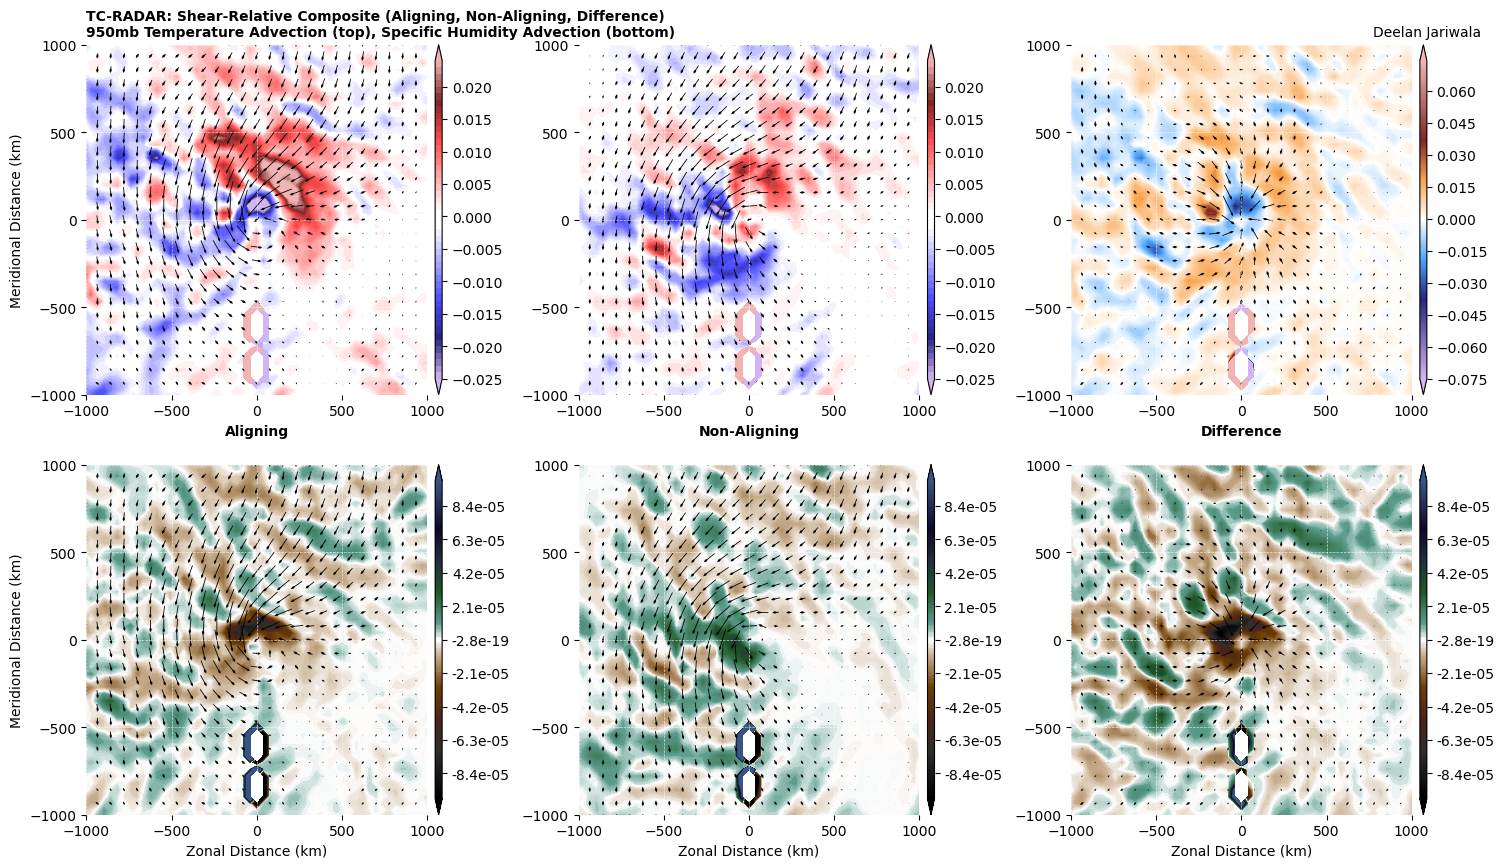

In [281]:
# ADVECTION

fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 3)

axes = [fig.add_subplot(1, 1, 1),
        fig.add_subplot(gs[0, 0]),
        fig.add_subplot(gs[0, 1]),
        fig.add_subplot(gs[0, 2]),
        fig.add_subplot(gs[1, 0]),
        fig.add_subplot(gs[1, 1]),
        fig.add_subplot(gs[1, 2]),
        ]

axes[0].set_xticks([])
axes[0].set_yticks([])
axes[0].set_frame_on(False)

var = tDat
flag = False
for ax in axes:
	if ax == axes[0]:
		i = 0
		continue
	if i > 2 and flag == False:
		var = qDat 
		i = i - 3
		flag = True

	xC, yC = np.gradient(np.nan_to_num(var[i], nan = 0.0), np.nan_to_num(Y[0, :], nan = 0.0), np.nan_to_num(X[:, 0], nan = 0.0))
	var[i] = (-(uDat[i] * xC + vDat[i] * yC)) #/ 1000
	
	ax.set_xlim(-1000, 1000)
	ax.set_ylim(-1000, 1000)
	ax.grid(linestyle = '--', alpha = 0.75, color = 'white', linewidth = 0.5, zorder = 9)
	ax.set_yticks(np.arange(-1000, 1500, 500))
	ax.set_xticks(np.arange(-1000, 1500, 500))

	if i == 0:
		ax.set_ylabel('Meridional Distance (km)')
	if flag == True:
		ax.set_xlabel('Zonal Distance (km)')
	else:
		if i == 0:
			ax.set_xlabel('Aligning', fontdict={'weight':'bold'})
		elif i == 1:
			ax.set_xlabel('Non-Aligning', fontdict={'weight':'bold'})
		else:
			ax.set_xlabel('Difference', fontdict={'weight':'bold'})
	ax.set_frame_on(False)

	if hgt in [1000, 850, 200, 950]:
		if flag == False and i == 2:
			c = ax.contourf(X, Y, var[i - 2] - var[i - 1], shading='auto', cmap=cmap.tempAnoms(), levels = np.arange(-.075, .075, 0.001), extend = 'both')
		elif flag == True and i == 2:
			c = ax.contourf(X, Y, var[i - 2] - var[i - 1], shading='auto', cmap = relh(), levels = np.arange(-1e-4, 1e-4, .01e-4), extend = 'both')
		elif flag == True:
			c = ax.contourf(X, Y, var[i], shading='auto', cmap=relh(), levels = np.arange(-1e-4, 1e-4, .01e-4), extend = 'both')
		else:
			c = ax.contourf(X, Y, var[i], shading='auto', cmap=cmap.tempAnoms3(), levels = np.arange(-.025, .025, .001), extend = 'both')
	elif hgt == 850:
		if flag == False and i == 2:
			c = ax.contourf(X, Y, var[i], shading='auto', cmap=cmap.tempAnoms(), levels = np.arange(-1, 1, 1e-2), extend = 'both')
		elif flag == True and i == 2:
			c = ax.contourf(X, Y, var[i], shading='auto', cmap = relh(), levels = np.arange(-2.5e-3, 2.5e-3, 2.5e-6), extend = 'both')
		elif flag == True:
			c = ax.contourf(X, Y, var[i], shading='auto', cmap=cmap.probs4(), levels = np.arange(0.005, 0.015, 5e-5), extend = 'both')
		else:
			c = ax.contourf(X, Y, var[i], shading='auto', cmap=cmap.probs4(), levels = np.arange(290, 292.5, .01), extend = 'both')
	elif hgt == 200:
		if flag == False and i == 2:
			c = ax.contourf(X, Y, var[i], shading='auto', cmap=cmap.tempAnoms(), levels = np.arange(-1, 1, 1e-2), extend = 'both')
		elif flag == True and i == 2:
			c = ax.contourf(X, Y, var[i], shading='auto', cmap = relh(), levels = np.arange(-2e-4, 2e-4, 2.5e-8), extend = 'both')
		elif flag == True:
			c = ax.contourf(X, Y, var[i], shading='auto', cmap=cmap.probs4(), levels = np.arange(0., 0.00011, 1e-6), extend = 'both')
		else:
			c = ax.contourf(X, Y, var[i], shading='auto', cmap=cmap.probs4(), levels = np.arange(219, 222.5, .01), extend = 'both')
	else:
		if flag == False and i == 2:
			c = ax.contourf(X, Y, var[i], shading='auto', cmap=cmap.tempAnoms(), levels = np.arange(-1, 1, 1e-2), extend = 'both')
		elif flag == True and i == 2:
			c = ax.contourf(X, Y, var[i], shading='auto', cmap = relh(), levels = np.arange(-2.5e-3, 2.5e-3, 2.5e-6), extend = 'both')
		elif flag == True:
			c = ax.contourf(X, Y, var[i], shading='auto', cmap=cmap.probs4(), levels = np.arange(0.000, 0.0025, 2.5e-5), extend = 'both')
		else:
			c = ax.contourf(X, Y, var[i], shading='auto', cmap=cmap.probs4(), levels = np.arange(255, 260, .01), extend = 'both')

		
	if flag == False:
		cb = plt.colorbar(c, orientation = 'vertical', aspect = 50, pad = .02)#, format='%.001f')
	
	else:
		cb = plt.colorbar(c, orientation = 'vertical', aspect = 50, pad = .02, format='%.1e')
	ax.quiver(X[::2, ::2], Y[::2, ::2], uDat[i][::2, ::2], vDat[i][::2, ::2], pivot = 'middle', scale = 150, minshaft = 2, minlength=0, headaxislength = 6, headlength = 3, color = 'black')
	i = i + 1

axes[0].set_title(f'TC-RADAR: Shear-Relative Composite (Aligning, Non-Aligning, Difference)\n{str(hgt)}mb Temperature Advection (top), Specific Humidity Advection (bottom)', fontweight='bold', fontsize=10, loc='left')
axes[0].set_title('Deelan Jariwala', fontsize=10, loc='right') 
plt.savefig(r"C:\Users\deela\Downloads\\thermoAdvComp" + str(hgt) + ".png", dpi = 400, bbox_inches = 'tight')
plt.show()

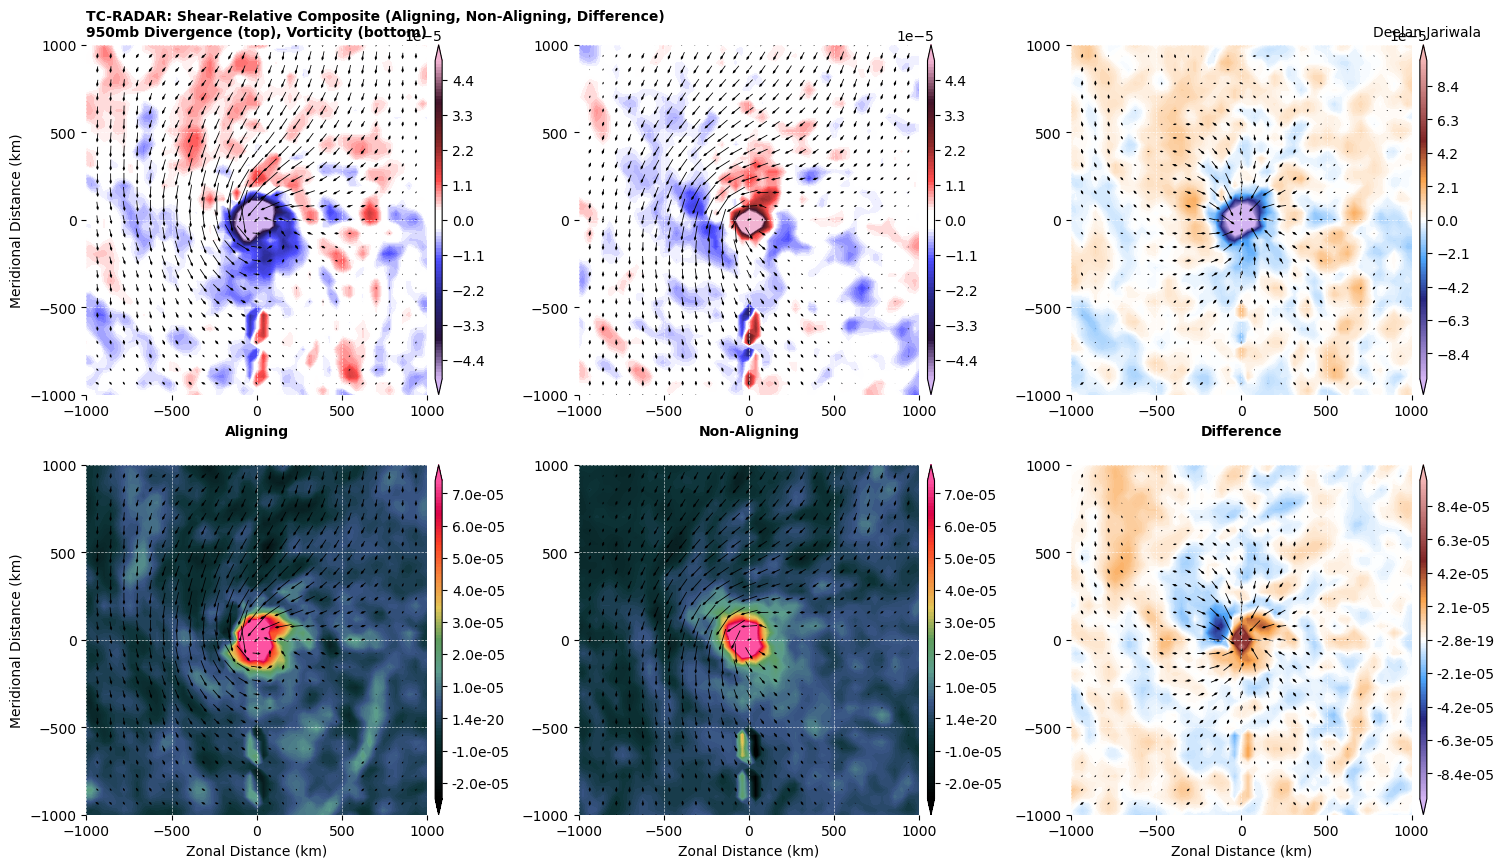

In [282]:
# CONVERGENCE

fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 3)

axes = [fig.add_subplot(1, 1, 1),
        fig.add_subplot(gs[0, 0]),
        fig.add_subplot(gs[0, 1]),
        fig.add_subplot(gs[0, 2]),
        fig.add_subplot(gs[1, 0]),
        fig.add_subplot(gs[1, 1]),
        fig.add_subplot(gs[1, 2]),
        ]

axes[0].set_xticks([])
axes[0].set_yticks([])
axes[0].set_frame_on(False)

var = tDat
flag = False
for ax in axes:
	if ax == axes[0]:
		i = 0
		continue
	if i > 2 and flag == False:
		var = qDat 
		i = i - 3
		flag = True

	fxx, fxy = np.gradient(np.nan_to_num(uDat[i], nan = 0.0), np.nan_to_num(Y[0, :], nan = 0.0), np.nan_to_num(X[:, 0], nan = 0.0))
	fyx, fyy = np.gradient(np.nan_to_num(vDat[i], nan = 0.0), np.nan_to_num(Y[0, :], nan = 0.0), np.nan_to_num(X[:, 0], nan = 0.0))
	xC, yC = np.gradient(np.nan_to_num(var[i], nan = 0.0), np.nan_to_num(Y[0, :], nan = 0.0), np.nan_to_num(X[:, 0], nan = 0.0))
	if flag == False:
		var[i] = (fxx + fyy) / 1000
	else:
		var[i] = (fyx - fxy) / 1000
	
	ax.set_xlim(-1000, 1000)
	ax.set_ylim(-1000, 1000)
	ax.grid(linestyle = '--', alpha = 0.75, color = 'white', linewidth = 0.5, zorder = 9)
	ax.set_yticks(np.arange(-1000, 1500, 500))
	ax.set_xticks(np.arange(-1000, 1500, 500))

	if i == 0:
		ax.set_ylabel('Meridional Distance (km)')
	if flag == True:
		ax.set_xlabel('Zonal Distance (km)')
	else:
		if i == 0:
			ax.set_xlabel('Aligning', fontdict={'weight':'bold'})
		elif i == 1:
			ax.set_xlabel('Non-Aligning', fontdict={'weight':'bold'})
		else:
			ax.set_xlabel('Difference', fontdict={'weight':'bold'})
	ax.set_frame_on(False)

	if hgt in [1000, 850, 200, 950]:
		if flag == False and i == 2:
			c = ax.contourf(X, Y, var[i - 2] - var[i - 1], shading='auto', cmap=cmap.tempAnoms(), levels = np.arange(-1e-4, 1e-4, .01e-4), extend = 'both')
		elif flag == True and i == 2:
			c = ax.contourf(X, Y, var[i - 2] - var[i - 1], shading='auto', cmap = cmap.tempAnoms(), levels = np.arange(-1e-4, 1e-4, .01e-4), extend = 'both')
		elif flag == True:
			c = ax.contourf(X, Y, var[i], shading='auto', cmap=cmap.probs4(), levels = np.arange(-.25e-4, .75e-4, .01e-4), extend = 'both')
		else:
			c = ax.contourf(X, Y, var[i], shading='auto', cmap=cmap.tempAnoms6(), levels = np.arange(-.5e-4, .5e-4, .01e-4), extend = 'both')
	elif hgt == 850:
		if flag == False and i == 2:
			c = ax.contourf(X, Y, var[i], shading='auto', cmap=cmap.tempAnoms(), levels = np.arange(-1, 1, 1e-2), extend = 'both')
		elif flag == True and i == 2:
			c = ax.contourf(X, Y, var[i], shading='auto', cmap = relh(), levels = np.arange(-2.5e-3, 2.5e-3, 2.5e-6), extend = 'both')
		elif flag == True:
			c = ax.contourf(X, Y, var[i], shading='auto', cmap=cmap.probs4(), levels = np.arange(0.005, 0.015, 5e-5), extend = 'both')
		else:
			c = ax.contourf(X, Y, var[i], shading='auto', cmap=cmap.probs4(), levels = np.arange(290, 292.5, .01), extend = 'both')
	elif hgt == 200:
		if flag == False and i == 2:
			c = ax.contourf(X, Y, var[i], shading='auto', cmap=cmap.tempAnoms(), levels = np.arange(-1, 1, 1e-2), extend = 'both')
		elif flag == True and i == 2:
			c = ax.contourf(X, Y, var[i], shading='auto', cmap = relh(), levels = np.arange(-2e-4, 2e-4, 2.5e-8), extend = 'both')
		elif flag == True:
			c = ax.contourf(X, Y, var[i], shading='auto', cmap=cmap.probs4(), levels = np.arange(0., 0.00011, 1e-6), extend = 'both')
		else:
			c = ax.contourf(X, Y, var[i], shading='auto', cmap=cmap.probs4(), levels = np.arange(219, 222.5, .01), extend = 'both')
	else:
		if flag == False and i == 2:
			c = ax.contourf(X, Y, var[i], shading='auto', cmap=cmap.tempAnoms(), levels = np.arange(-1, 1, 1e-2), extend = 'both')
		elif flag == True and i == 2:
			c = ax.contourf(X, Y, var[i], shading='auto', cmap = relh(), levels = np.arange(-2.5e-3, 2.5e-3, 2.5e-6), extend = 'both')
		elif flag == True:
			c = ax.contourf(X, Y, var[i], shading='auto', cmap=cmap.probs4(), levels = np.arange(0.000, 0.0025, 2.5e-5), extend = 'both')
		else:
			c = ax.contourf(X, Y, var[i], shading='auto', cmap=cmap.probs4(), levels = np.arange(255, 260, .01), extend = 'both')

		
	if flag == False:
		cb = plt.colorbar(c, orientation = 'vertical', aspect = 50, pad = .02)#, format='%.001f')
	
	else:
		cb = plt.colorbar(c, orientation = 'vertical', aspect = 50, pad = .02, format='%.1e')
	ax.quiver(X[::2, ::2], Y[::2, ::2], uDat[i][::2, ::2], vDat[i][::2, ::2], pivot = 'middle', scale = 150, minshaft = 2, minlength=0, headaxislength = 6, headlength = 3, color = 'black')
	i = i + 1

axes[0].set_title(f'TC-RADAR: Shear-Relative Composite (Aligning, Non-Aligning, Difference)\n{str(hgt)}mb Divergence (top), Vorticity (bottom)', fontweight='bold', fontsize=10, loc='left')
axes[0].set_title('Deelan Jariwala', fontsize=10, loc='right') 
plt.savefig(r"C:\Users\deela\Downloads\\thermoDivComp" + str(hgt) + ".png", dpi = 400, bbox_inches = 'tight')
plt.show()

In [283]:
data = dataset['temperature']
data = data.sel(level = hgt - 50)
ddir = dataset['shear_dir']
tM, newTheta, offsets = process(data, ddir)

data = dataset['temperature']
data = data.sel(level = hgt + 50)
ddir = dataset['shear_dir']
tP, newTheta, offsets = process(data, ddir)

1510
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
2

In [284]:
tM1 = tM[varShort].sel(case = alignment, r = slice(0, 1500)).mean('case')
tM2 = tM[varShort].sel(case = misalign, r = slice(0, 1500)).mean('case')
TM = [tM1, tM2, tM1 - tM2]

tP1 = tM[varShort].sel(case = alignment, r = slice(0, 1500)).mean('case')
tP2 = tM[varShort].sel(case = misalign, r = slice(0, 1500)).mean('case')
TP = [tP1, tP2, tP1 - tP2]

tMDat, tPDat = [], []

for i in TM:
    X, Y, tMData = rectangle(i)
    tMDat.append(tMData)
for i in TP:
    X, Y, tPData = rectangle(i)
    tPDat.append(tPData)

(27720, 2) (27720,) (77, 77) (77, 77)
(27720, 2) (27720,) (77, 77) (77, 77)
(27720, 2) (27720,) (77, 77) (77, 77)
(27720, 2) (27720,) (77, 77) (77, 77)
(27720, 2) (27720,) (77, 77) (77, 77)
(27720, 2) (27720,) (77, 77) (77, 77)


In [219]:
from helper import theta
p = 50

def pvNew():
    newcmp = LinearSegmentedColormap.from_list("", [
    (0/12, "#802525"),
    (7.5/12, "#faa44d"),
    (8/12, "#FFFFFF"),
    (10/12, "#4da4fa"),
    (12/12, "#252580")])

    return newcmp.reversed()

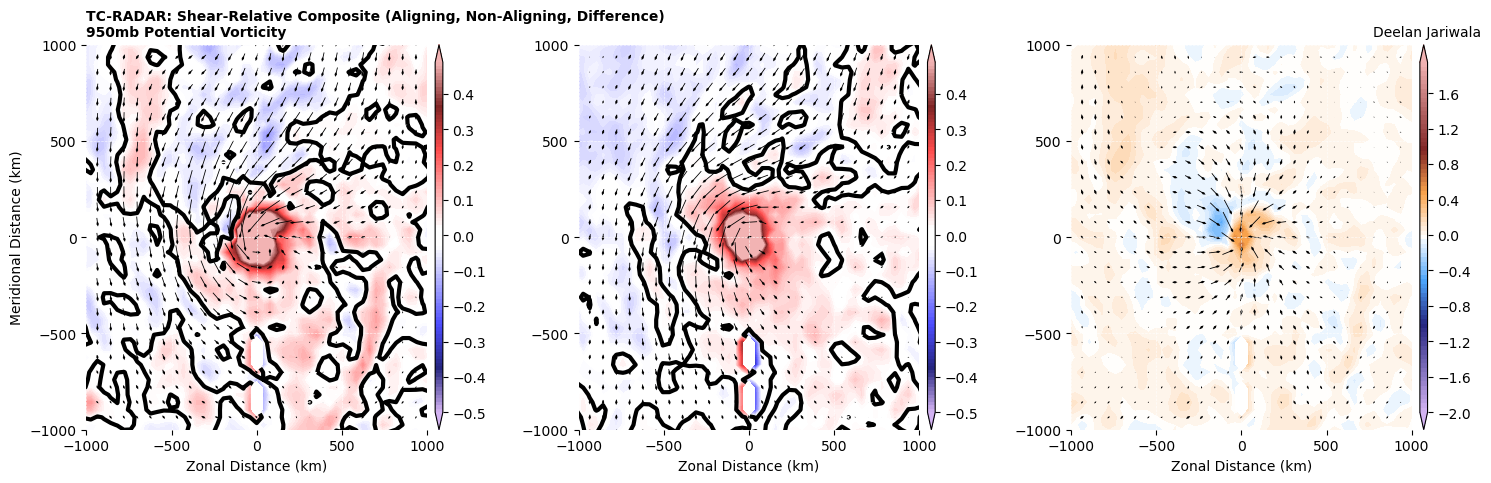

In [289]:
# CONVERGENCE

fig = plt.figure(figsize=(18, 5))
gs = fig.add_gridspec(1, 3)

axes = [fig.add_subplot(1, 1, 1),
        fig.add_subplot(gs[0, 0]),
        fig.add_subplot(gs[0, 1]),
        fig.add_subplot(gs[0, 2]),
        ]

axes[0].set_xticks([])
axes[0].set_yticks([])
axes[0].set_frame_on(False)

var = tDat
for ax in axes:
	if ax == axes[0]:
		i = 0
		continue

	fxx, fxy = np.gradient(np.nan_to_num(uDat[i], nan = 0.0), np.nan_to_num(Y[0, :], nan = 0.0), np.nan_to_num(X[:, 0], nan = 0.0))
	fyx, fyy = np.gradient(np.nan_to_num(vDat[i], nan = 0.0), np.nan_to_num(Y[0, :], nan = 0.0), np.nan_to_num(X[:, 0], nan = 0.0))
	xC, yC = np.gradient(np.nan_to_num(var[i], nan = 0.0), np.nan_to_num(Y[0, :], nan = 0.0), np.nan_to_num(X[:, 0], nan = 0.0))

	td = (theta(tMDat[i], hgt - p, 1000) - theta(tPDat[i], hgt + p, 1000)) / (p * 200)

	fxx, fxy = np.gradient(np.nan_to_num(uDat[i], nan = 0.0), np.nan_to_num(Y[0, :], nan = 0.0), np.nan_to_num(X[:, 0], nan = 0.0))
	fyx, fyy = np.gradient(np.nan_to_num(vDat[i], nan = 0.0), np.nan_to_num(Y[0, :], nan = 0.0), np.nan_to_num(X[:, 0], nan = 0.0))
	vort = (fyx - fxy) / 1000

	var[i] = 9.81 * vort * td * 1e6
	
	ax.set_xlim(-1000, 1000)
	ax.set_ylim(-1000, 1000)
	ax.grid(linestyle = '--', alpha = 0.75, color = 'white', linewidth = 0.5, zorder = 9)
	ax.set_yticks(np.arange(-1000, 1500, 500))
	ax.set_xticks(np.arange(-1000, 1500, 500))

	if i == 0:
		ax.set_ylabel('Meridional Distance (km)')
	ax.set_xlabel('Zonal Distance (km)')
	ax.set_frame_on(False)

	if hgt in [1000, 850, 250, 950]:
		if i == 2:
			c = ax.contourf(X, Y, var[i - 2] - var[i - 1], shading='auto', cmap=cmap.tempAnoms(), levels = np.arange(-2, 2, .05), extend = 'both')
		else:
			c = ax.contourf(X, Y, var[i], shading='auto', cmap=cmap.tempAnoms3(), levels = np.arange(-.5, .5, 0.01), extend = 'both')
			ax.contour(X, Y, var[i], shading='auto', colors = 'black', linewidths = 3, levels = 0)
		
	cb = plt.colorbar(c, orientation = 'vertical', aspect = 50, pad = .02)
	ax.quiver(X[::2, ::2], Y[::2, ::2], uDat[i][::2, ::2], vDat[i][::2, ::2], pivot = 'middle', scale = 150, minshaft = 2, minlength=0, headaxislength = 6, headlength = 3, color = 'black')
	i = i + 1

axes[0].set_title(f'TC-RADAR: Shear-Relative Composite (Aligning, Non-Aligning, Difference)\n{str(hgt)}mb Potential Vorticity', fontweight='bold', fontsize=10, loc='left')
axes[0].set_title('Deelan Jariwala', fontsize=10, loc='right') 
plt.savefig(r"C:\Users\deela\Downloads\\pvComp" + str(hgt) + ".png", dpi = 400, bbox_inches = 'tight')
plt.show()

In [ ]:
# MOISTURE FLUX CONVERGENCE (MFC)

fig = plt.figure(figsize=(18, 5))
gs = fig.add_gridspec(1, 3)

axes = [fig.add_subplot(1, 1, 1),
        fig.add_subplot(gs[0, 0]),
        fig.add_subplot(gs[0, 1]),
        fig.add_subplot(gs[0, 2]),
        ]

axes[0].set_xticks([])
axes[0].set_yticks([])
axes[0].set_frame_on(False)

# Recompute rectangular grids from un-mutated xarray composites
# (qDat/uDat/vDat were overwritten in earlier cells)
qDat2, uDat2, vDat2 = [], [], []
for da in Q:
    X, Y, d = rectangle(da)
    qDat2.append(d)
for da in U:
    X, Y, d = rectangle(da)
    uDat2.append(d)
for da in V:
    X, Y, d = rectangle(da)
    vDat2.append(d)

# MFC = -(d(qu)/dx + d(qv)/dy)
# Using same gradient convention as existing cells: np.gradient(f, Y[0,:], X[:,0])
# returns (df/dx, df/dy)
mfcDat = []
for i in range(3):
    qu = np.nan_to_num(qDat2[i], nan=0.0) * np.nan_to_num(uDat2[i], nan=0.0)
    qv = np.nan_to_num(qDat2[i], nan=0.0) * np.nan_to_num(vDat2[i], nan=0.0)
    dqu_dx, _  = np.gradient(qu, np.nan_to_num(Y[0, :], nan=0.0), np.nan_to_num(X[:, 0], nan=0.0))
    _,  dqv_dy = np.gradient(qv, np.nan_to_num(Y[0, :], nan=0.0), np.nan_to_num(X[:, 0], nan=0.0))
    mfcDat.append(-(dqu_dx + dqv_dy))

for ax in axes:
    if ax == axes[0]:
        i = 0
        continue

    ax.set_xlim(-1000, 1000)
    ax.set_ylim(-1000, 1000)
    ax.grid(linestyle='--', alpha=0.75, color='white', linewidth=0.5, zorder=9)
    ax.set_yticks(np.arange(-1000, 1500, 500))
    ax.set_xticks(np.arange(-1000, 1500, 500))

    if i == 0:
        ax.set_ylabel('Meridional Distance (km)')
        ax.set_xlabel('Aligning', fontdict={'weight': 'bold'})
    elif i == 1:
        ax.set_xlabel('Non-Aligning', fontdict={'weight': 'bold'})
    else:
        ax.set_xlabel('Difference', fontdict={'weight': 'bold'})
    ax.set_frame_on(False)

    if i == 2:
        c = ax.contourf(X, Y, mfcDat[0] - mfcDat[1], cmap=cmap.tempAnoms(),
                        levels=np.arange(-5e-5, 5e-5, 5e-7), extend='both')
    else:
        c = ax.contourf(X, Y, mfcDat[i], cmap=relh(),
                        levels=np.arange(-1e-4, 1e-4, 1e-6), extend='both')

    cb = plt.colorbar(c, orientation='vertical', aspect=50, pad=.02, format='%.1e')
    ax.quiver(X[::2, ::2], Y[::2, ::2], uDat2[i][::2, ::2], vDat2[i][::2, ::2],
              pivot='middle', scale=150, minshaft=2, minlength=0,
              headaxislength=6, headlength=3, color='black')
    i += 1

axes[0].set_title(f'TC-RADAR: Shear-Relative Composite (Aligning, Non-Aligning, Difference)\n{str(hgt)}mb Moisture Flux Convergence', fontweight='bold', fontsize=10, loc='left')
axes[0].set_title('Deelan Jariwala', fontsize=10, loc='right')
plt.savefig(r"C:\Users\deela\Downloads\\mfcComp" + str(hgt) + ".png", dpi=400, bbox_inches='tight')
plt.show()

In [ ]:
# OKUBO-WEISS (strain vs rotation)

# Recompute rectangular grids from un-mutated composites
uDat2, vDat2 = [], []
for da in U:
    X, Y, d = rectangle(da)
    uDat2.append(d)
for da in V:
    X, Y, d = rectangle(da)
    vDat2.append(d)

owDat = []
owScale = 1e12  # scale factor for readability
for i in range(3):
    u = np.nan_to_num(uDat2[i], nan=0.0)
    v = np.nan_to_num(vDat2[i], nan=0.0)
    du_dx, du_dy = np.gradient(u, np.nan_to_num(Y[0, :], nan=0.0), np.nan_to_num(X[:, 0], nan=0.0))
    dv_dx, dv_dy = np.gradient(v, np.nan_to_num(Y[0, :], nan=0.0), np.nan_to_num(X[:, 0], nan=0.0))

    sn = du_dx - dv_dy
    ss = dv_dx + du_dy
    vort = dv_dx - du_dy

    ow = ((sn**2 + ss**2) - vort**2) * owScale
    owDat.append(ow)

fig = plt.figure(figsize=(18, 5))
gs = fig.add_gridspec(1, 3)

axes = [fig.add_subplot(1, 1, 1),
        fig.add_subplot(gs[0, 0]),
        fig.add_subplot(gs[0, 1]),
        fig.add_subplot(gs[0, 2]),
        ]

axes[0].set_xticks([])
axes[0].set_yticks([])
axes[0].set_frame_on(False)

# symmetric levels for each panel (aligning/non-aligning/difference)
mx = np.nanmax(np.abs(np.stack(owDat[:2])))
if not np.isfinite(mx) or mx == 0:
    mx = 1e-10
mx_diff = np.nanmax(np.abs(owDat[0] - owDat[1]))
if not np.isfinite(mx_diff) or mx_diff == 0:
    mx_diff = mx

for ax in axes:
    if ax == axes[0]:
        i = 0
        continue

    ax.set_xlim(-1000, 1000)
    ax.set_ylim(-1000, 1000)
    ax.grid(linestyle='--', alpha=0.75, color='white', linewidth=0.5, zorder=9)
    ax.set_yticks(np.arange(-1000, 1500, 500))
    ax.set_xticks(np.arange(-1000, 1500, 500))

    if i == 0:
        ax.set_ylabel('Meridional Distance (km)')
        ax.set_xlabel('Aligning', fontdict={'weight': 'bold'})
    elif i == 1:
        ax.set_xlabel('Non-Aligning', fontdict={'weight': 'bold'})
    else:
        ax.set_xlabel('Difference', fontdict={'weight': 'bold'})
    ax.set_frame_on(False)

    if i == 2:
        levels = np.linspace(-mx_diff, mx_diff, 41)
        c = ax.contourf(X, Y, owDat[0] - owDat[1], cmap=cmap.tempAnoms(), levels=levels, extend='both')
    else:
        levels = np.linspace(-mx, mx, 41)
        c = ax.contourf(X, Y, owDat[i], cmap=cmap.tempAnoms(), levels=levels, extend='both')

    cb = plt.colorbar(c, orientation='vertical', aspect=50, pad=.02, format='%.2g')
    ax.quiver(X[::2, ::2], Y[::2, ::2], uDat2[i][::2, ::2], vDat2[i][::2, ::2],
              pivot='middle', scale=150, minshaft=2, minlength=0,
              headaxislength=6, headlength=3, color='black')
    i += 1

axes[0].set_title(f'TC-RADAR: Shear-Relative Composite (Aligning, Non-Aligning, Difference)\n{str(hgt)}mb Okubo-Weiss (strain vs rotation) x1e12',
                 fontweight='bold', fontsize=10, loc='left')
axes[0].set_title('Deelan Jariwala', fontsize=10, loc='right')
plt.savefig(r"C:\Users\deela\Downloads\owComp" + str(hgt) + ".png", dpi=400, bbox_inches='tight')
plt.show()
